{'Population': 0.0990513736602193, 'TotalCensus': 0.09634101268941728, 'Age_0-4_Ptge': 0.0, 'Age_under19_Ptge': 0.0, 'Age_19_65_pct': 0.002833559196747567, 'Age_over65_pct': 0.0, 'WomanPopulationPtge': 0.002587162744856474, 'ForeignersPtge': 0.0052975237156584944, 'SameComAutonPtge': 0.0, 'SameComAutonDiffProvPtge': 0.020327707281015153, 'DifComAutonPtge': 0.004927929037821855, 'UnemployLess25_Ptge': 0.003203153874584206, 'Unemploy25_40_Ptge': 0.0, 'UnemployMore40_Ptge': 0.0, 'AgricultureUnemploymentPtge': 0.019958112603178514, 'IndustryUnemploymentPtge': 0.005913514845386226, 'ConstructionUnemploymentPtge': 0.006529505975113958, 'ServicesUnemploymentPtge': 0.0, 'totalEmpresas': 0.0, 'Industria': 0.0, 'Construccion': 0.0, 'ComercTTEHosteleria': 0.0, 'Servicios': 0.0, 'inmuebles': 0.0, 'Pob2010': 0.0, 'SUPERFICIE': 0.0, 'PobChange_pct': 0.008131082912406062, 'PersonasInmueble': 0.0, 'Explotaciones': 0.0}


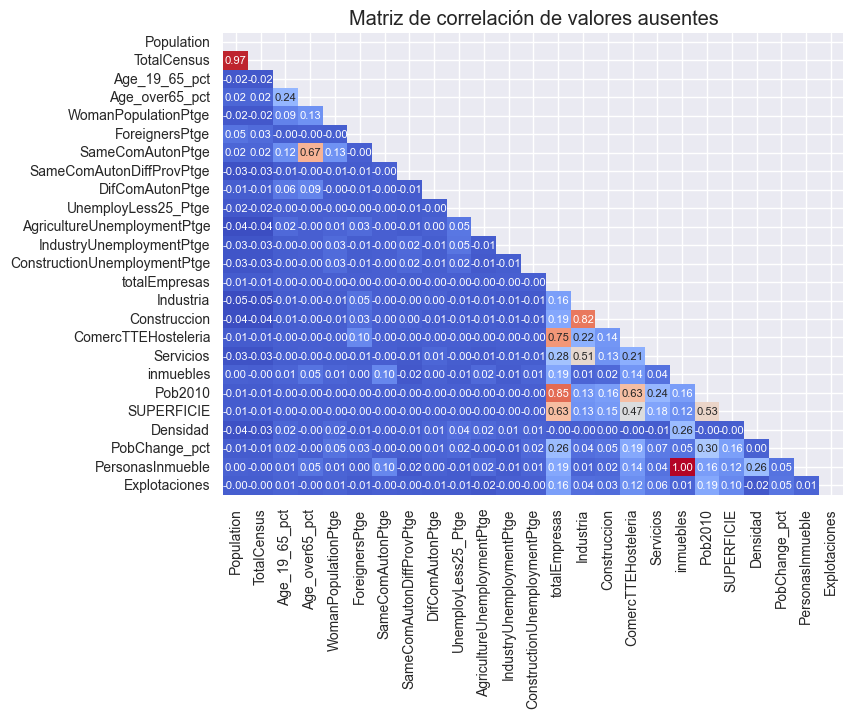

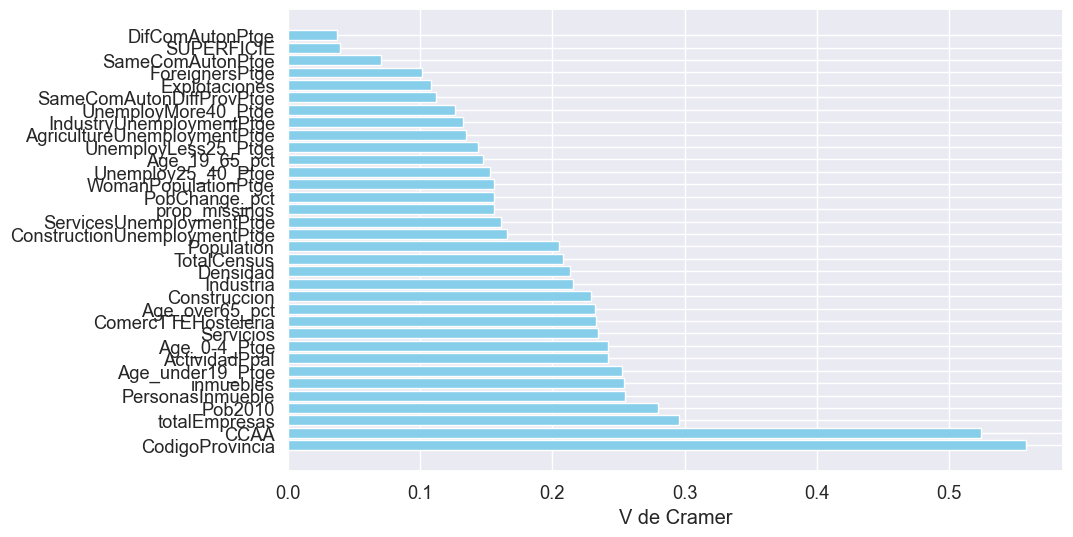

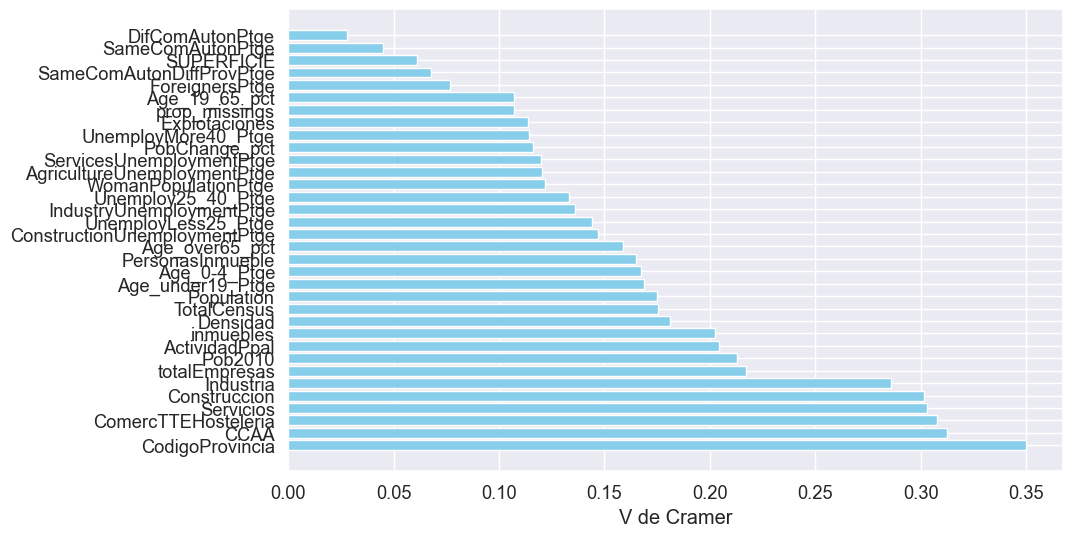

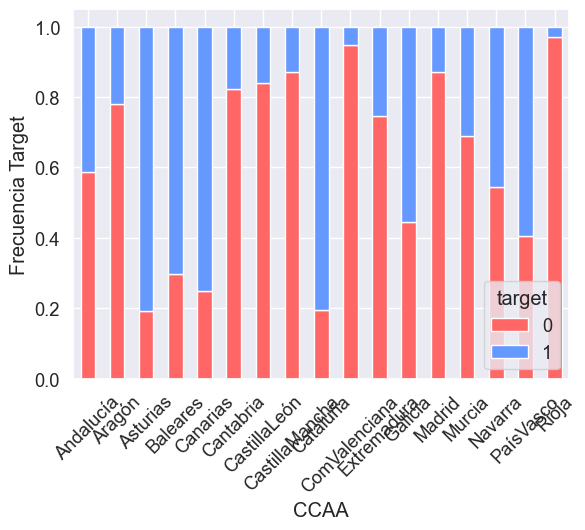

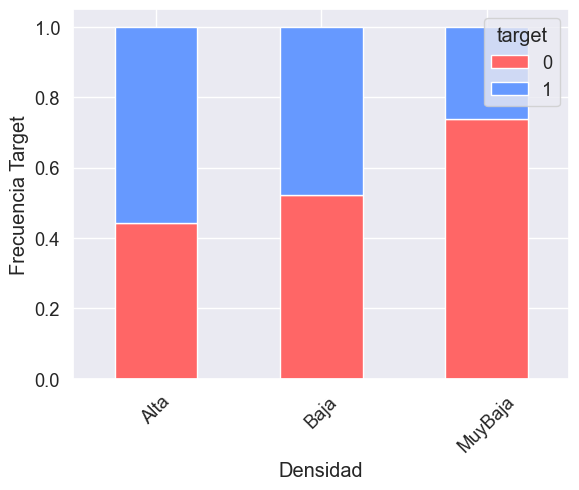

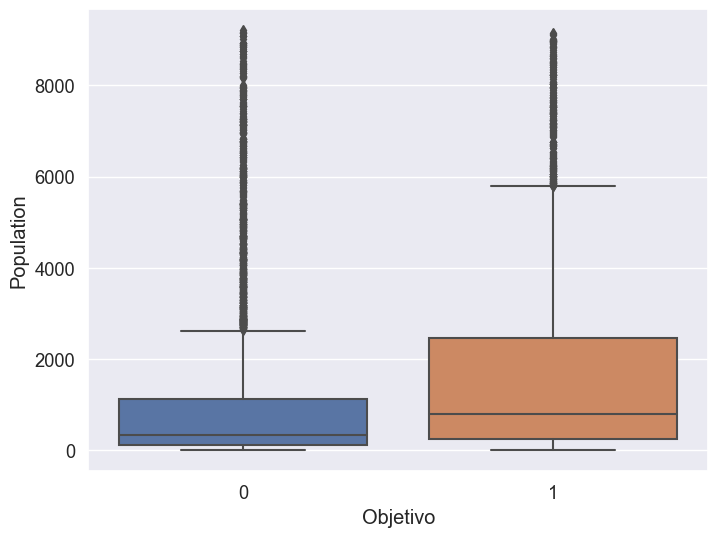

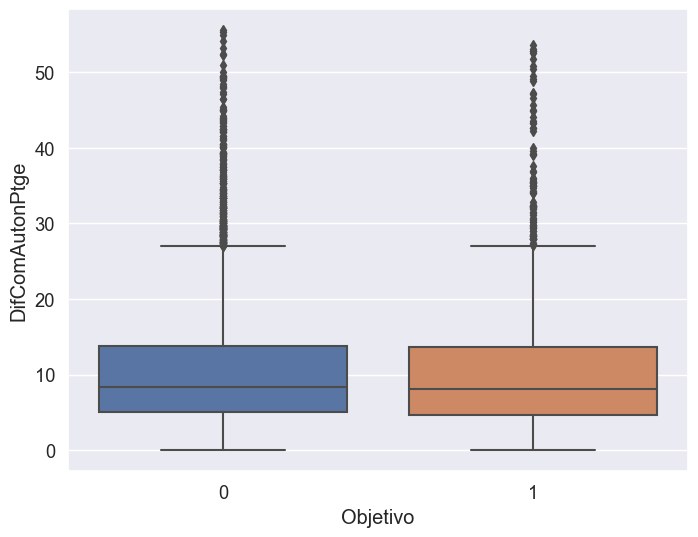

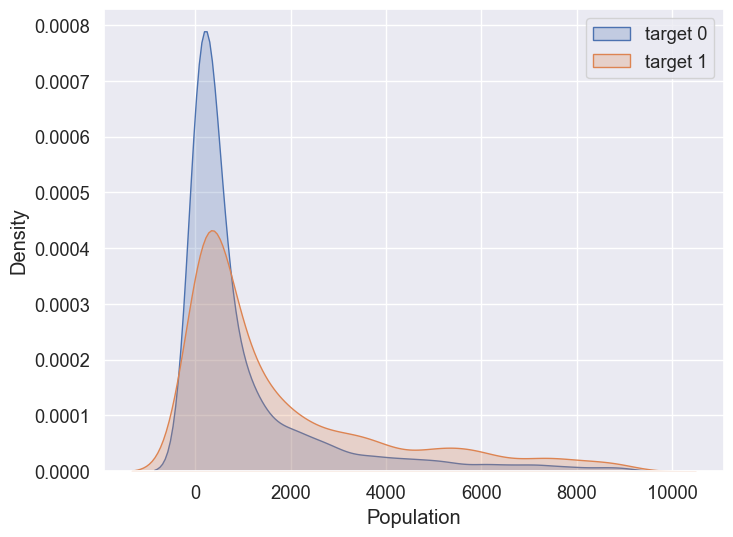

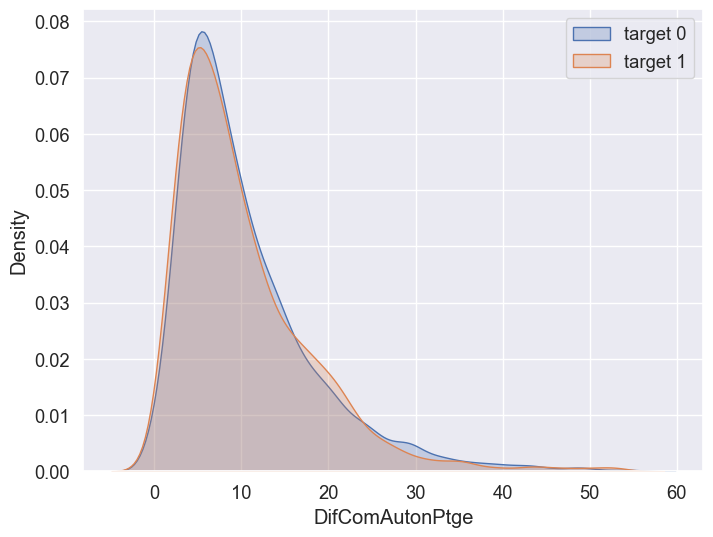

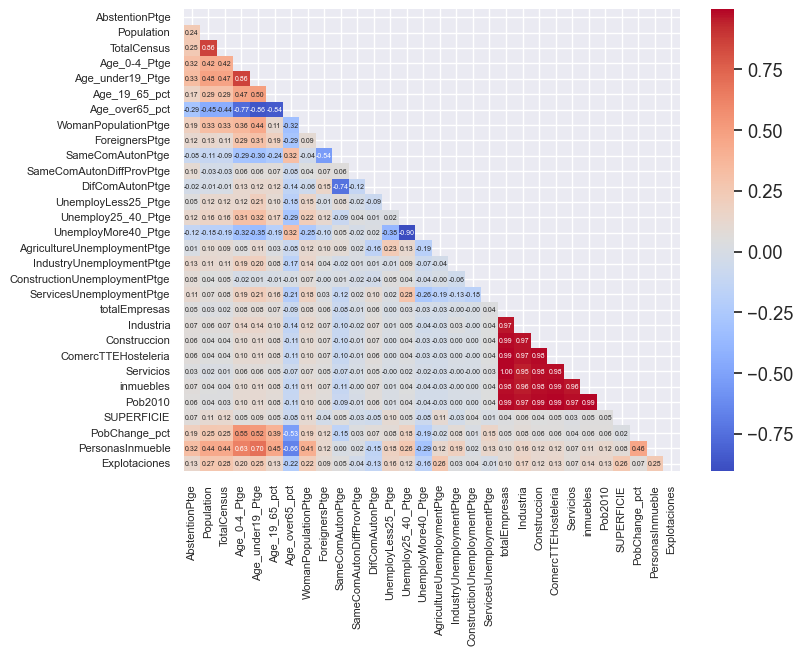

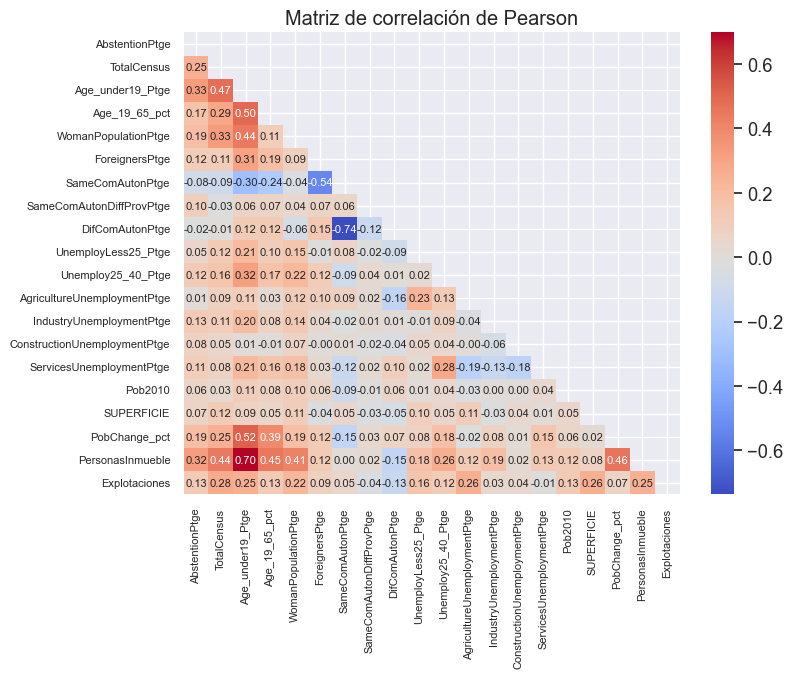

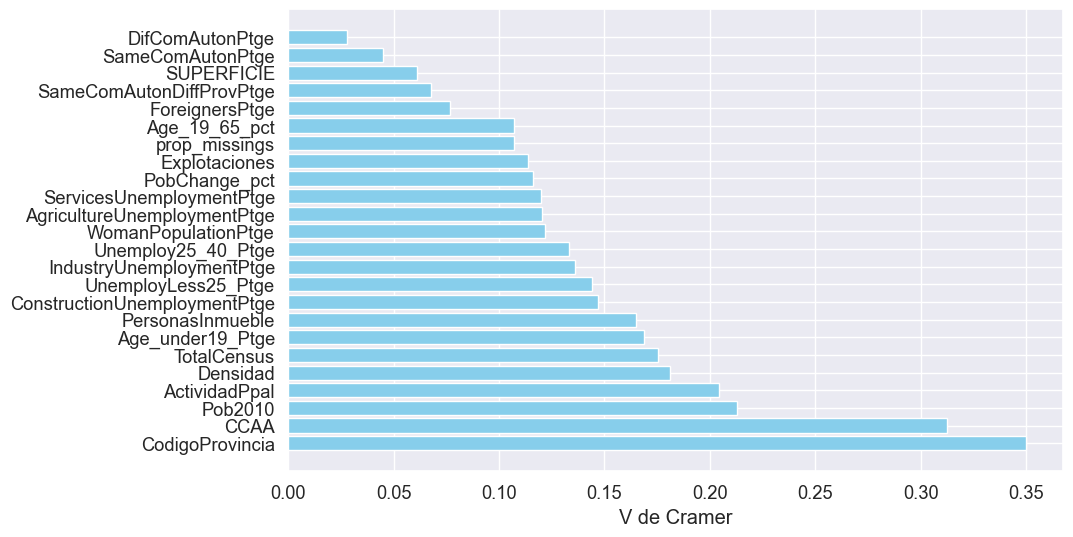

In [8]:
# Importo las librerías necesarias
import os
from sklearn.model_selection import train_test_split
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns
import pickle

# Elijo el directorio de trabajo e importo las funciones necesarias
os.chdir(r'C:/Users/lrodr/OneDrive/Documentos/master_ucm/trabajos/6')
from FuncionesMineria import (analizar_variables_categoricas, cuentaDistintos, atipicosAmissing, 
                              patron_perdidos, ImputacionCuant, ImputacionCuali, Vcramer, graficoVcramer, 
                              mosaico_targetbinaria, boxplot_targetbinaria, hist_targetbinaria, Rsq,
                              summary_glm, validacion_cruzada_lm, validacion_cruzada_glm,
                              lm_forward, lm_backward, lm_stepwise, glm_forward, glm_backward, glm_stepwise, 
                              modelEffectSizes, impVariablesLog, curva_roc, sensEspCorte, crear_data_modelo, 
                              pseudoR2)

# Cargo los datos
datos = pd.read_excel('DatosEleccionesEspaña.xlsx')

#Elimino las variables objetivo descartadas
datos=datos.drop(['Dcha_Pct', 'Izda_Pct', 'Otros_Pct', 'Derecha', 'Izquierda'], axis=1)

# Compruebo el tipo de formato de las variables que se han asignado en la lectura.
datos.dtypes

# Indico las categóricas que aparecen como numéricas
numericasAcategoricas = ['CodigoProvincia', 'AbstencionAlta']

# Las transformo en categóricas
for var in numericasAcategoricas:
    datos[var] = datos[var].astype(str)

# Genero una lista con los nombres de las variables.
variables = list(datos.columns)  

# Selecciono las columnas numéricas del DataFrame
numericas = datos.select_dtypes(include=['int', 'int32', 'int64','float', 'float32', 'float64']).columns

# Selecciono las columnas categóricas del DataFrame
categoricas = [variable for variable in variables if variable not in numericas]
 
# Frecuencias de los valores en las variables categóricas
analizar_variables_categoricas(datos)

# Cuento el número de valores distintos de cada una de las variables numéricas de un DataFrame, y compruebo que no hay ninguna que tenga menos de 10 valores diferentes
cuentaDistintos(datos) 

# Compruebo que todas las variables tienen el formato que quiero 
datos.dtypes

# Descriptivos de las variables numéricas
descriptivos_num = datos.describe().T

# Añado más descriptivos a los anteriores
for num in numericas:
    descriptivos_num.loc[num, "Asimetria"] = datos[num].skew()
    descriptivos_num.loc[num, "Kurtosis"] = datos[num].kurtosis()
    descriptivos_num.loc[num, "Rango"] = np.ptp(datos[num].dropna().values)

# Muestro valores perdidos
datos[variables].isna().sum()

# A veces los 'nan' vienen como como una cadena de caracteres, los modifico a perdidos
datos[categoricas] = datos[categoricas].replace('nan', np.nan)

# Missings no declarados de variables cualitativas (NSNC, ?)
datos['Densidad'] = datos['Densidad'].replace('?', np.nan)

# Missings no declarados variables cuantitativas (-1, 99999)
datos['Explotaciones'] = datos['Explotaciones'].replace(99999, np.nan)

# Valores fuera de rango
datos['AbstentionPtge'] = [x if 0 <= x <= 100 else np.nan for x in datos['AbstentionPtge']]
datos['Age_0-4_Ptge'] = [x if 0 <= x <= 100 else np.nan for x in datos['Age_0-4_Ptge']]
datos['Age_under19_Ptge'] = [x if 0 <= x <= 100 else np.nan for x in datos['Age_under19_Ptge']]
datos['Age_19_65_pct'] = [x if 0 <= x <= 100 else np.nan for x in datos['Age_19_65_pct']]
datos['Age_over65_pct'] = [x if 0 <= x <= 100 else np.nan for x in datos['Age_over65_pct']]
datos['WomanPopulationPtge'] = [x if 0 <= x <= 100 else np.nan for x in datos['WomanPopulationPtge']]
datos['ForeignersPtge'] = [x if -100 <= x <= 100 else np.nan for x in datos['ForeignersPtge']]
datos['SameComAutonPtge'] = [x if 0 <= x <= 100 else np.nan for x in datos['SameComAutonPtge']]
datos['SameComAutonDiffProvPtge'] = [x if 0 <= x <= 100 else np.nan for x in datos['SameComAutonDiffProvPtge']]
datos['DifComAutonPtge'] = [x if 0 <= x <= 100 else np.nan for x in datos['DifComAutonPtge']]
datos['UnemployLess25_Ptge'] = [x if 0 <= x <= 100 else np.nan for x in datos['UnemployLess25_Ptge']]
datos['Unemploy25_40_Ptge'] = [x if 0 <= x <= 100 else np.nan for x in datos['Unemploy25_40_Ptge']]
datos['UnemployMore40_Ptge'] = [x if 0 <= x <= 100 else np.nan for x in datos['UnemployMore40_Ptge']]
datos['AgricultureUnemploymentPtge'] = [x if 0 <= x <= 100 else np.nan for x in datos['AgricultureUnemploymentPtge']]
datos['IndustryUnemploymentPtge'] = [x if 0 <= x <= 100 else np.nan for x in datos['IndustryUnemploymentPtge']]
datos['ConstructionUnemploymentPtge'] = [x if 0 <= x <= 100 else np.nan for x in datos['ConstructionUnemploymentPtge']]
datos['ServicesUnemploymentPtge'] = [x if 0 <= x <= 100 else np.nan for x in datos['ServicesUnemploymentPtge']]
datos['PobChange_pct'] = [x if -100 <= x <= 100 else np.nan for x in datos['PobChange_pct']]

# Junto categorías poco representadas de las variables categóricas
datos['ActividadPpal'] = datos['ActividadPpal'].replace({'Construccion': 'Const-Ind', 'Industria': 'Const-Ind'})
# Agrupar "Industria" y "Construcción" en una sola categoría tiene sentido debido a su baja representación relativa 
# (menos del 0.2% del total), lo que podría generar problemas de significancia estadística y sesgos en el análisis. 
# Además, ambas pertenecen al sector secundario, compartiendo similitudes conceptuales relacionadas con la transformación 
#de materiales e infraestructuras. Este agrupamiento también simplifica el análisis, facilita la interpretación de resultados 
# y previene problemas derivados del desequilibrio en las categorías.

# Indico la variableObj, el ID y las Input 
datos = datos.set_index(datos['Name']).drop('Name', axis = 1)
varObjCont = datos['AbstentionPtge']
varObjBin = datos['AbstencionAlta']
datos_input = datos.drop(['AbstentionPtge', 'AbstencionAlta'], axis = 1)

# Genero una lista con los nombres de las variables del cojunto de datos input.
variables_input = list(datos_input.columns)  

# Seleciono las variables numéricas
numericas_input = datos_input.select_dtypes(include = ['int', 'int32', 'int64','float', 'float32', 'float64']).columns

# Seleciono las variables categóricas
categoricas_input = [variable for variable in variables_input if variable not in numericas_input]


# ATIPICOS

# Cuento el porcentaje de atipicos de cada variable. 
resultados = {x: atipicosAmissing(datos_input[x])[1] / len(datos_input) for x in numericas_input}

# Modifico los atipicos como missings
for x in numericas_input:
    datos_input[x] = atipicosAmissing(datos_input[x])[0]
print(resultados)

# MISSINGS
# Visualizo un mapa de calor que muestra la matriz de correlación de valores ausentes en el conjunto de datos.
patron_perdidos(datos_input)

# Muestro el total de valores perdidos por cada variable
datos_input[variables_input].isna().sum()

# Guardo la proporción de valores perdidos por cada variable en una nueva variable
prop_missingsVars = datos_input.isna().sum()/len(datos_input)

# Creo la variable prop_missings que recoge el número de valores perdidos por cada observación
datos_input['prop_missings'] = datos_input.isna().mean(axis = 1)

# Realizo un estudio descriptivo básico a la nueva variable
datos_input['prop_missings'].describe()

# Calculo el número de valores distintos que tiene la nueva variable
len(datos_input['prop_missings'].unique()) #No la convierto en categórica por futuras incompatibilidades con el modelo de regresión logística

# Elimino las observaciones con mas de la mitad de datos missings 
eliminar = datos_input['prop_missings'] > 0.5
datos_input = datos_input[~eliminar]
varObjBin = varObjBin[~eliminar]
varObjCont = varObjCont[~eliminar]

# Agrego 'prop_missings' a la lista de nombres de variables input
variables_input.append('prop_missings')
numericas_input.append('prop_missings')

# Elimino las variables con mas de la mitad de datos missings (no hay ninguna)
eliminar = [prop_missingsVars.index[x] for x in range(len(prop_missingsVars)) if prop_missingsVars[x] > 0.5]
datos_input = datos_input.drop(eliminar, axis = 1)

# No considero necesario recategorizar las variables categóricas analizadas porque todas presentan una 
# distribución suficientemente representativa o ya están estructuradas de manera adecuada para el análisis. 
# Por ejemplo, variables como CodigoProvincia y CCAA ofrecen información detallada y diferenciada por 
# regiones geográficas, cuya agregación podría llevar a la pérdida de información relevante. Las variables 
# binarias, como AbstencionAlta, Izquierda y Derecha, están correctamente definidas y no presentan niveles 
# adicionales ni valores faltantes que justifiquen ajustes. Además, la variable Densidad, aunque categórica, 
# tiene tres niveles bien distribuidos y suficientemente representativos, lo que no compromete la robustez de 
# los análisis posteriores. Por lo tanto, las variables categóricas actuales no requieren recategorización 
# para cumplir los objetivos del estudio.

## IMPUTACIONES
# Imputo todas las cuantitativas, seleccionando el tipo de imputacion: media, mediana o aleatorio
for x in numericas_input:
    datos_input[x] = ImputacionCuant(datos_input[x], 'aleatorio')

# Imputo todas las cualitativas, seleccionando el tipo de imputacion: moda o aleatorio
for x in categoricas_input:
    datos_input[x] = ImputacionCuali(datos_input[x], 'aleatorio')

# Reviso que no queden datos missings
datos_input.isna().sum()

# Una vez finalizado este proceso, se puede considerar que los datos estan depurados. Los guardo
datosEleccionesDep = pd.concat([varObjBin, varObjCont, datos_input], axis = 1)
with open('datosEleccionesDep.pickle', 'wb') as archivo:
    pickle.dump(datosEleccionesDep, archivo) 

# Obtengo la importancia de las variables
graficoVcramer(datos_input, varObjBin)
graficoVcramer(datos_input, varObjCont)

# Crear un DataFrame para almacenar los resultados del coeficiente V de Cramer
VCramer = pd.DataFrame(columns=['Variable', 'Objetivo', 'Vcramer'])

for variable in variables_input:
    v_cramer = Vcramer(datos_input[variable], varObjCont)
    VCramer = VCramer.append({'Variable': variable, 'Objetivo': varObjCont.name, 'Vcramer': v_cramer},
                             ignore_index=True)
    
for variable in variables_input:
    v_cramer = Vcramer(datos_input[variable], varObjBin)
    VCramer = VCramer.append({'Variable': variable, 'Objetivo': varObjBin.name, 'Vcramer': v_cramer},
                             ignore_index=True)

# Veo graficamente el efecto de dos variables cualitativas sobre la binaria
mosaico_targetbinaria(datos_input['CCAA'], varObjBin, 'CCAA')
mosaico_targetbinaria(datos_input['Densidad'], varObjBin, 'Densidad')

# Veo graficamente el efecto de dos variables cuantitativas sobre la binaria
boxplot_targetbinaria(datos_input['Population'], varObjBin,'Objetivo', 'Population')
boxplot_targetbinaria(datos_input['DifComAutonPtge'], varObjBin, 'Objetivo','DifComAutonPtge')

hist_targetbinaria(datos_input['Population'], varObjBin, 'Population')
hist_targetbinaria(datos_input['DifComAutonPtge'], varObjBin, 'DifComAutonPtge')

# Correlación entre todas las variables numéricas frente a la objetivo continua 
numericas = datos_input.select_dtypes(include=['int', 'float']).columns
matriz_corr = pd.concat([varObjCont, datos_input[numericas]], axis = 1).corr(method = 'pearson')
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)
sns.heatmap(matriz_corr, annot=True, annot_kws={"size": 5}, cmap='coolwarm', fmt=".2f", cbar=True, mask=mask)
plt.yticks(
    ticks=np.arange(len(matriz_corr.index)) + 0.5, 
    labels=matriz_corr.index,  
    rotation=0, 
    fontsize=8 
)    
plt.xticks(
    ticks=np.arange(len(matriz_corr.columns)) + 0.5, 
    labels=matriz_corr.columns,  
    rotation=90,  
    fontsize=8 
)
plt.show()

# Ante la aparente multicolinealidad, vamos a eliminar algunas de las variables
datos_input = datos_input.drop(['Industria', 'Construccion', 'Servicios', 'Population', 
                                'totalEmpresas', 'inmuebles', 'ComercTTEHosteleria', 'Age_0-4_Ptge', 
                                'UnemployMore40_Ptge', 'Age_over65_pct'], axis=1)

# Vuelvo a mostrar la matriz de correlación 
numericas = datos_input.select_dtypes(include=['int', 'float']).columns
matriz_corr = pd.concat([varObjCont, datos_input[numericas]], axis = 1).corr(method = 'pearson')
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)
sns.heatmap(matriz_corr, annot=True, annot_kws={"size": 8}, cmap='coolwarm', fmt=".2f", cbar=True, mask=mask)
plt.yticks(
    ticks=np.arange(len(matriz_corr.index)) + 0.5, 
    labels=matriz_corr.index,  
    rotation=0, 
    fontsize=8
)    
plt.xticks(
    ticks=np.arange(len(matriz_corr.columns)) + 0.5, 
    labels=matriz_corr.columns, 
    rotation=90, 
    fontsize=8  
)
plt.title("Matriz de correlación de Pearson")
plt.show()

# CONSTRUCCIÓN DEL MODELO DE REGRESIÓN LINEAL

# Identifico las variables continuas 
var_cont = ['TotalCensus', 'Age_under19_Ptge', 'Age_19_65_pct', 'WomanPopulationPtge',  
            'ForeignersPtge', 'SameComAutonPtge', 'SameComAutonDiffProvPtge', 'DifComAutonPtge', 
            'UnemployLess25_Ptge', 'Unemploy25_40_Ptge', 'AgricultureUnemploymentPtge', 'IndustryUnemploymentPtge', 
            'ConstructionUnemploymentPtge', 'ServicesUnemploymentPtge', 'Pob2010', 'SUPERFICIE', 'PobChange_pct', 
            'PersonasInmueble', 'Explotaciones']

# Identifico las variables categóricas
var_categ = ['CodigoProvincia', 'CCAA', 'ActividadPpal', 'Densidad', 'prop_missings']

# Hago la particion
x_train, x_test, y_train, y_test = train_test_split(datos_input, varObjCont, test_size = 0.2, random_state = 1234567)

# Dado que la capacidad computacional de mi ordenador es limitada, he decidido reducir el número de posibles interacciones entre variables continuas en los modelos. 
# Para ello, utilizo la V de Cramer como criterio para seleccionar las variables más relevantes, enfocándome en aquellas que muestran una relación lógica y 
# potencial entre sí. En este análisis, incluyo variables continuas vinculadas a la estructura económica y demográfica, tales como ComercTTEHostelería, Construcción, 
# Servicios e Industria, ya que representan aspectos económicos clave que podrían interactuar para explicar los niveles de abstención.
# Asimismo, incorporo variables demográficas y de infraestructura como Population, TotalCensus y Densidad, las cuales reflejan la escala poblacional y la distribución 
# de recursos en los municipios. Estas interacciones me permiten explorar cómo la combinación de factores económicos y demográficos influye en los niveles de 
# participación electoral, logrando un equilibrio entre la complejidad y la relevancia del modelo.

# Interacciones 2 a 2 sólo de las variables continuas
# He seleccionado las mejores variables continuas basándome en su V de Cramer, priorizando aquellas que tienen la mayor 
# asociación con la variable dependiente. Dado que la capacidad computacional de mi ordenador es limitada, no es viable 
# crear interacciones entre todas las variables continuas disponibles, ya que esto implicaría calcular combinaciones 
# exponencialmente más complejas. Por lo tanto, elegir un subconjunto de las mejores variables permite reducir la complejidad 
# del modelo y optimizar los recursos sin sacrificar demasiada precisión en los resultados. Estas 10 variables representan 
# las que tienen mayor probabilidad de aportar información relevante al modelo, maximizando la eficiencia del análisis.
graficoVcramer(datos_input, varObjCont)
#interacciones = var_cont
interacciones = ['Pob2010', 'TotalCensus', 'Age_under19_Ptge', 'PersonasInmueble', 'ConstructionUnemploymentPtge', 
                 'UnemployLess25_Ptge', 'IndustryUnemploymentPtge', 'Unemploy25_40_Ptge']
interacciones_unicas = list(itertools.combinations(interacciones, 2))


In [9]:
# Seleccion de variables Backward, métrica AIC
modeloBackAIC = lm_backward(y_train, x_train, var_cont, var_categ, interacciones_unicas, 'AIC')

Start: AIC = 41076.93649463598

y ~ TotalCensus + Age_under19_Ptge + Age_19_65_pct + WomanPopulationPtge + ForeignersPtge + SameComAutonPtge + SameComAutonDiffProvPtge + DifComAutonPtge + UnemployLess25_Ptge + Unemploy25_40_Ptge + AgricultureUnemploymentPtge + IndustryUnemploymentPtge + ConstructionUnemploymentPtge + ServicesUnemploymentPtge + Pob2010 + SUPERFICIE + PobChange_pct + PersonasInmueble + Explotaciones + CodigoProvincia + CCAA + ActividadPpal + Densidad + prop_missings + Pob2010*TotalCensus + Pob2010*Age_under19_Ptge + Pob2010*PersonasInmueble + Pob2010*ConstructionUnemploymentPtge + Pob2010*UnemployLess25_Ptge + Pob2010*IndustryUnemploymentPtge + Pob2010*Unemploy25_40_Ptge + TotalCensus*Age_under19_Ptge + TotalCensus*PersonasInmueble + TotalCensus*ConstructionUnemploymentPtge + TotalCensus*UnemployLess25_Ptge + TotalCensus*IndustryUnemploymentPtge + TotalCensus*Unemploy25_40_Ptge + Age_under19_Ptge*PersonasInmueble + Age_under19_Ptge*ConstructionUnemploymentPtge + Age_unde

In [10]:
Rsq(modeloBackAIC['Modelo'], y_train, modeloBackAIC['X'])

0.4331611196273921

In [11]:
x_test_modeloBackAIC = crear_data_modelo(x_test, modeloBackAIC['Variables']['cont'], modeloBackAIC['Variables']['categ'], modeloBackAIC['Variables']['inter'])
Rsq(modeloBackAIC['Modelo'], y_test, x_test_modeloBackAIC)

0.42085246054061676

In [12]:
len(modeloBackAIC['Modelo'].params)

74

In [13]:
# Seleccion de variables Backward, métrica BIC
modeloBackBIC = lm_backward(y_train, x_train, var_cont, var_categ, interacciones_unicas, 'BIC')
Rsq(modeloBackBIC['Modelo'], y_train, modeloBackBIC['X'])

Start: BIC = 41815.7908094594

y ~ TotalCensus + Age_under19_Ptge + Age_19_65_pct + WomanPopulationPtge + ForeignersPtge + SameComAutonPtge + SameComAutonDiffProvPtge + DifComAutonPtge + UnemployLess25_Ptge + Unemploy25_40_Ptge + AgricultureUnemploymentPtge + IndustryUnemploymentPtge + ConstructionUnemploymentPtge + ServicesUnemploymentPtge + Pob2010 + SUPERFICIE + PobChange_pct + PersonasInmueble + Explotaciones + CodigoProvincia + CCAA + ActividadPpal + Densidad + prop_missings + Pob2010*TotalCensus + Pob2010*Age_under19_Ptge + Pob2010*PersonasInmueble + Pob2010*ConstructionUnemploymentPtge + Pob2010*UnemployLess25_Ptge + Pob2010*IndustryUnemploymentPtge + Pob2010*Unemploy25_40_Ptge + TotalCensus*Age_under19_Ptge + TotalCensus*PersonasInmueble + TotalCensus*ConstructionUnemploymentPtge + TotalCensus*UnemployLess25_Ptge + TotalCensus*IndustryUnemploymentPtge + TotalCensus*Unemploy25_40_Ptge + Age_under19_Ptge*PersonasInmueble + Age_under19_Ptge*ConstructionUnemploymentPtge + Age_under

0.4284799832657915

In [14]:
x_test_modeloBackBIC = crear_data_modelo(x_test, modeloBackBIC['Variables']['cont'], modeloBackBIC['Variables']['categ'], modeloBackBIC['Variables']['inter'])
Rsq(modeloBackBIC['Modelo'], y_test, x_test_modeloBackBIC)

0.4152402475009853

In [15]:
len(modeloBackBIC['Modelo'].params)

66

In [16]:
# Seleccion de variables Forward, métrica AIC
modeloForwAIC = lm_forward(y_train, x_train, var_cont, var_categ, interacciones_unicas, 'AIC')
Rsq(modeloForwAIC['Modelo'], y_train, modeloForwAIC['X'])

Start: AIC = 44573.50641861909

y ~ 1

                                                       Variable          AIC
                                              + CodigoProvincia 41684.532709
                                                         + CCAA 42165.778194
                     + ('Age_under19_Ptge', 'PersonasInmueble') 43802.238127
                                             + Age_under19_Ptge 43827.294288
                                             + PersonasInmueble 43871.424898
                                                + ActividadPpal 43885.815696
                   + ('Age_under19_Ptge', 'Unemploy25_40_Ptge') 44019.001350
                   + ('PersonasInmueble', 'Unemploy25_40_Ptge') 44039.448950
                                                  + TotalCensus 44173.408865
              + ('TotalCensus', 'ConstructionUnemploymentPtge') 44193.579147
                                                     + Densidad 44195.788518
                        + ('TotalCens

0.43102798042448465

In [17]:
x_test_modeloForwAIC = crear_data_modelo(x_test, modeloForwAIC['Variables']['cont'], modeloForwAIC['Variables']['categ'], modeloForwAIC['Variables']['inter'])
Rsq(modeloForwAIC['Modelo'], y_test, x_test_modeloForwAIC)

0.41715290012509343

In [18]:
len(modeloForwAIC['Modelo'].params)

75

In [19]:
# Seleccion de variables Forward, métrica BIC
modeloForwBIC = lm_forward(y_train, x_train, var_cont, var_categ, interacciones_unicas, 'BIC')
Rsq(modeloForwBIC['Modelo'], y_train, modeloForwBIC['X'])

Start: BIC = 44580.2848985716

y ~ 1

                                                       Variable          BIC
                                              + CodigoProvincia 42023.456707
                                                         + CCAA 42281.012353
                     + ('Age_under19_Ptge', 'PersonasInmueble') 43815.795087
                                             + Age_under19_Ptge 43840.851248
                                             + PersonasInmueble 43884.981857
                                                + ActividadPpal 43912.929616
                   + ('Age_under19_Ptge', 'Unemploy25_40_Ptge') 44032.558310
                   + ('PersonasInmueble', 'Unemploy25_40_Ptge') 44053.005910
                                                  + TotalCensus 44186.965825
              + ('TotalCensus', 'ConstructionUnemploymentPtge') 44207.136107
                                                     + Densidad 44216.123958
                        + ('TotalCensu

0.42439754619792025

In [20]:
x_test_modeloForwBIC = crear_data_modelo(x_test, modeloForwBIC['Variables']['cont'], modeloForwBIC['Variables']['categ'], modeloForwBIC['Variables']['inter'])
Rsq(modeloForwBIC['Modelo'], y_test, x_test_modeloForwBIC)

0.41140944572866434

In [21]:
len(modeloForwBIC['Modelo'].params)

62

In [22]:
# Seleccion de variables Stepwise, métrica AIC
modeloStepAIC = lm_stepwise(y_train, x_train, var_cont, var_categ, interacciones_unicas, 'AIC')
Rsq(modeloStepAIC['Modelo'], y_train, modeloStepAIC['X'])

Start: AIC = 44573.50641861909

y ~ 1

                                                       Variable          AIC
                                              + CodigoProvincia 41684.532709
                                                         + CCAA 42165.778194
                     + ('Age_under19_Ptge', 'PersonasInmueble') 43802.238127
                                             + Age_under19_Ptge 43827.294288
                                             + PersonasInmueble 43871.424898
                                                + ActividadPpal 43885.815696
                   + ('Age_under19_Ptge', 'Unemploy25_40_Ptge') 44019.001350
                   + ('PersonasInmueble', 'Unemploy25_40_Ptge') 44039.448950
                                                  + TotalCensus 44173.408865
              + ('TotalCensus', 'ConstructionUnemploymentPtge') 44193.579147
                                                     + Densidad 44195.788518
                        + ('TotalCens

0.43063103243507705

In [23]:

x_test_modeloStepAIC = crear_data_modelo(x_test, modeloStepAIC['Variables']['cont'], modeloStepAIC['Variables']['categ'], modeloStepAIC['Variables']['inter'])
Rsq(modeloStepAIC['Modelo'], y_test, x_test_modeloStepAIC)

0.4191446754593715

In [24]:
len(modeloStepAIC['Modelo'].params)

72

In [25]:
# Seleccion de variables Stepwise, métrica BIC, con interacciones
modeloStepBIC = lm_stepwise(y_train, x_train, var_cont, var_categ, interacciones_unicas, 'BIC')
Rsq(modeloStepBIC['Modelo'], y_train, modeloStepBIC['X'])

Start: BIC = 44580.2848985716

y ~ 1

                                                       Variable          BIC
                                              + CodigoProvincia 42023.456707
                                                         + CCAA 42281.012353
                     + ('Age_under19_Ptge', 'PersonasInmueble') 43815.795087
                                             + Age_under19_Ptge 43840.851248
                                             + PersonasInmueble 43884.981857
                                                + ActividadPpal 43912.929616
                   + ('Age_under19_Ptge', 'Unemploy25_40_Ptge') 44032.558310
                   + ('PersonasInmueble', 'Unemploy25_40_Ptge') 44053.005910
                                                  + TotalCensus 44186.965825
              + ('TotalCensus', 'ConstructionUnemploymentPtge') 44207.136107
                                                     + Densidad 44216.123958
                        + ('TotalCensu

0.42439754619792025

In [26]:
x_test_modeloStepBIC = crear_data_modelo(x_test, modeloStepBIC['Variables']['cont'], modeloStepBIC['Variables']['categ'], modeloStepBIC['Variables']['inter'])
Rsq(modeloStepBIC['Modelo'], y_test, x_test_modeloStepBIC)
 
# De acuerdo con los resultados obtenidos, el modelo seleccionado sería el método Forward con BIC, ya que logra un equilibrio óptimo entre rendimiento y simplicidad.

0.41140944572866434

In [27]:
len(modeloStepBIC['Modelo'].params)

62

In [ ]:
# SELECCIÓN ALEATORIA DE VARIABLES 
# Inicializo un diccionario para almacenar las fórmulas y variables seleccionadas.
variables_seleccionadas = {
    'Formula': [],
    'Variables': []
}

# Realizo 30 iteraciones de selección aleatoria.
for x in range(30):
    print('---------------------------- iter: ' + str(x))
    
    # Divido los datos de entrenamiento en conjuntos de entrenamiento y prueba.
    x_train2, x_test2, y_train2, y_test2 = train_test_split(x_train, y_train, test_size = 0.3, random_state = 1234567 + x)
    
    # Realizo la selección stepwise utilizando el criterio BIC en la submuestra.
    modelo = lm_forward(y_train2.astype(int), x_train2, var_cont, var_categ, interacciones_unicas, 'BIC')
    
    # Almaceno las variables seleccionadas y la fórmula correspondiente.
    variables_seleccionadas['Variables'].append(modelo['Variables'])
    variables_seleccionadas['Formula'].append(sorted(modelo['Modelo'].model.exog_names))

# Uno las variables en las fórmulas seleccionadas en una sola cadena.
variables_seleccionadas['Formula'] = list(map(lambda x: '+'.join(x), variables_seleccionadas['Formula']))
    
# Calculo la frecuencia de cada fórmula y ordenarlas por frecuencia.
frecuencias = Counter(variables_seleccionadas['Formula'])
frec_ordenada = pd.DataFrame(list(frecuencias.items()), columns = ['Formula', 'Frecuencia'])
frec_ordenada = frec_ordenada.sort_values('Frecuencia', ascending = False).reset_index()

# Identifico las dos modelos más frecuentes y las variables correspondientes.
var_1 = variables_seleccionadas['Variables'][variables_seleccionadas['Formula'].index(
    frec_ordenada['Formula'][0])]
var_2 = variables_seleccionadas['Variables'][variables_seleccionadas['Formula'].index(
    frec_ordenada['Formula'][1])]
var_3 = variables_seleccionadas['Variables'][variables_seleccionadas['Formula'].index(
    frec_ordenada['Formula'][2])]


## Comparacion final, tomo el ganador de antes y los nuevos candidatos
results = pd.DataFrame({
    'Rsquared': []
    , 'Resample': []
    , 'Modelo': []
})
for rep in range(20):
    modelo1 = validacion_cruzada_lm(
        5
        , x_train
        , y_train
        , modeloForwBIC['Variables']['cont']
        , modeloForwBIC['Variables']['categ']
        , modeloForwBIC['Variables']['inter']
    )
    modelo2 = validacion_cruzada_lm(
        5
        , x_train
        , y_train
        , var_1['cont']
        , var_1['categ']
        , var_1['inter']
    )
    modelo3 = validacion_cruzada_lm(
        5
        , x_train
        , y_train
        , var_2['cont']
        , var_2['categ']
        , var_2['inter']
    )
    modelo4 = validacion_cruzada_lm(
        5
        , x_train
        , y_train
        , var_3['cont']
        , var_3['categ']
        , var_3['inter']
    )
        
    results_rep = pd.DataFrame({
        'Rsquared': modelo1 + modelo2 + modelo3 + modelo4
        , 'Resample': ['Rep' + str((rep + 1))]*5*4
        , 'Modelo': [1]*5 + [2]*5 + [3]*5 +[4]*5
    })
    results = pd.concat([results, results_rep], axis = 0)

# Boxplot de la validacion cruzada 
plt.figure(figsize=(10, 6))  
plt.grid(True) 
grupo_metrica = results.groupby('Modelo')['Rsquared']
boxplot_data = [grupo_metrica.get_group(grupo).tolist() for grupo in grupo_metrica.groups]
plt.boxplot(boxplot_data, labels=grupo_metrica.groups.keys()) 
plt.xlabel('Modelo')
plt.ylabel('R_cuadrado')
plt.show()  

In [30]:

# Calculo la media de las métricas R-squared por modelo
media_r2 = results.groupby('Modelo')['Rsquared'].mean()
print (media_r2)

Modelo
1.0    0.409870
2.0    0.406500
3.0    0.406521
4.0    0.410818
Name: Rsquared, dtype: float64


In [31]:
# Calcular la desviación estándar de las métricas R-squared por modelo
std_r2 = results.groupby('Modelo')['Rsquared'].std()
print(std_r2)

Modelo
1.0    0.029191
2.0    0.026672
3.0    0.027381
4.0    0.026663
Name: Rsquared, dtype: float64


In [32]:
# Cuento el número de parámetros en cada modelo
num_params = [len(modeloForwBIC['Modelo'].params), 
                 len(frec_ordenada['Formula'][0].split('+')),
                 len(frec_ordenada['Formula'][1].split('+')),
                 len(frec_ordenada['Formula'][2].split('+'))]
print(num_params)

[62, 57, 58, 62]


In [44]:
var_3

{'cont': ['SameComAutonPtge',
  'Explotaciones',
  'ServicesUnemploymentPtge',
  'ConstructionUnemploymentPtge',
  'AgricultureUnemploymentPtge',
  'Age_19_65_pct',
  'TotalCensus'],
 'categ': ['CodigoProvincia', 'ActividadPpal'],
 'inter': [('TotalCensus', 'PersonasInmueble'),
  ('Age_under19_Ptge', 'PersonasInmueble')]}

In [45]:
ModeloGanador = lm_forward(y_train, x_train, var_3['cont'], var_3['categ'], var_3['inter'], 'BIC')

# Muestro el resumen de statsmodels
ModeloGanador['Modelo'].summary()
# Todos los parámetros del modelo son significativos

Start: BIC = 44580.2848985716

y ~ 1

                                   Variable          BIC
                          + CodigoProvincia 42023.456707
 + ('Age_under19_Ptge', 'PersonasInmueble') 43815.795087
                            + ActividadPpal 43912.929616
                              + TotalCensus 44186.965825
      + ('TotalCensus', 'PersonasInmueble') 44221.516847
                            + Age_19_65_pct 44396.805634
                 + ServicesUnemploymentPtge 44489.637808
                            + Explotaciones 44497.256030
                         + SameComAutonPtge 44528.325556
             + ConstructionUnemploymentPtge 44544.328770
              + AgricultureUnemploymentPtge 44588.633005

--------------------------------------- Step Forward: Entra CodigoProvincia

AIC = 42023.45670703368

y ~ CodigoProvincia

                                   Variable          BIC
                            + ActividadPpal 41756.831423
                         + SameComAutonP

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         AbstentionPtge   R-squared:                       0.424
Model:                            OLS   Adj. R-squared:                  0.418
Method:                 Least Squares   F-statistic:                     78.83
Date:                Sat, 25 Jan 2025   Prob (F-statistic):               0.00
Time:                        20:16:51   Log-Likelihood:                -20496.
No. Observations:                6493   AIC:                         4.111e+04
Df Residuals:                    6432   BIC:                         4.153e+04
Df Model:                          60                                         
Covariance Type:            nonrobust                                         
=====================================================================================================
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const                                39.0833      1.403     27.848      0.000      36.332      41.834
SameComAutonPtge                     -0.0937      0.008    -12.057      0.000      -0.109      -0.078
Explotaciones                         0.0025      0.000      6.711      0.000       0.002       0.003
ConstructionUnemploymentPtge          0.0307      0.007      4.475      0.000       0.017       0.044
ServicesUnemploymentPtge              0.0128      0.003      4.015      0.000       0.007       0.019
TotalCensus                           0.0014      0.000      6.284      0.000       0.001       0.002
Age_19_65_pct                        -0.0516      0.013     -3.897      0.000      -0.078      -0.026
CodigoProvincia_10                   -3.3850      0.967     -3.501      0.000      -5.280      -1.490
CodigoProvincia_11                    3.9937      1.362      2.933      0.003       1.324       6.663
CodigoProvincia_12                   -9.2238      1.018     -9.058      0.000     -11.220      -7.228
CodigoProvincia_13                   -5.6431      1.076     -5.243      0.000      -7.753      -3.533
CodigoProvincia_14                   -4.4899      1.158     -3.877      0.000      -6.760      -2.219
CodigoProvincia_15                    1.0131      1.116      0.908      0.364      -1.175       3.201
CodigoProvincia_16                   -7.5702      0.960     -7.886      0.000      -9.452      -5.688
CodigoProvincia_17                    3.7801      0.956      3.956      0.000       1.907       5.653
CodigoProvincia_18                   -1.3412      1.000     -1.341      0.180      -3.301       0.619
CodigoProvincia_19                   -9.2150      0.951     -9.693      0.000     -11.079      -7.351
CodigoProvincia_2                    -6.9361      1.097     -6.325      0.000      -9.086      -4.786
CodigoProvincia_20                    6.1596      1.088      5.659      0.000       4.026       8.293
CodigoProvincia_21                    2.9548      1.119      2.640      0.008       0.760       5.149
CodigoProvincia_22                   -3.2042      0.968     -3.310      0.001      -5.102      -1.307
CodigoProvincia_23                   -6.6892      1.099     -6.089      0.000      -8.843      -4.536
CodigoProvincia_24                   -0.8557      0.974     -0.878      0.380      -2.766       1.055
CodigoProvincia_25                    7.0410      0.955      7.374      0.000       5.169       8.913
CodigoProvincia_26                  -10.0262      0.987    -10.155      0.000     -11.962      -8.091
CodigoProvincia_27                    0.1045      1.226      0.085      0.932      -2.298       2.507
CodigoProvincia_28                   -6.5579      0.982     -6.680      0.000      -8.482      -4.633
CodigoProvincia_29     

In [46]:

# Evalúo la estabilidad del modelo a partir de las diferencias en train y test
Rsq(ModeloGanador['Modelo'], y_train, ModeloGanador['X'])

0.4237612287216389

In [47]:
x_test_modeloganador = crear_data_modelo(x_test, ModeloGanador['Variables']['cont'], ModeloGanador['Variables']['categ'], ModeloGanador['Variables']['inter'])
Rsq(ModeloGanador['Modelo'], y_test, x_test_modeloganador)

0.41255161298279974

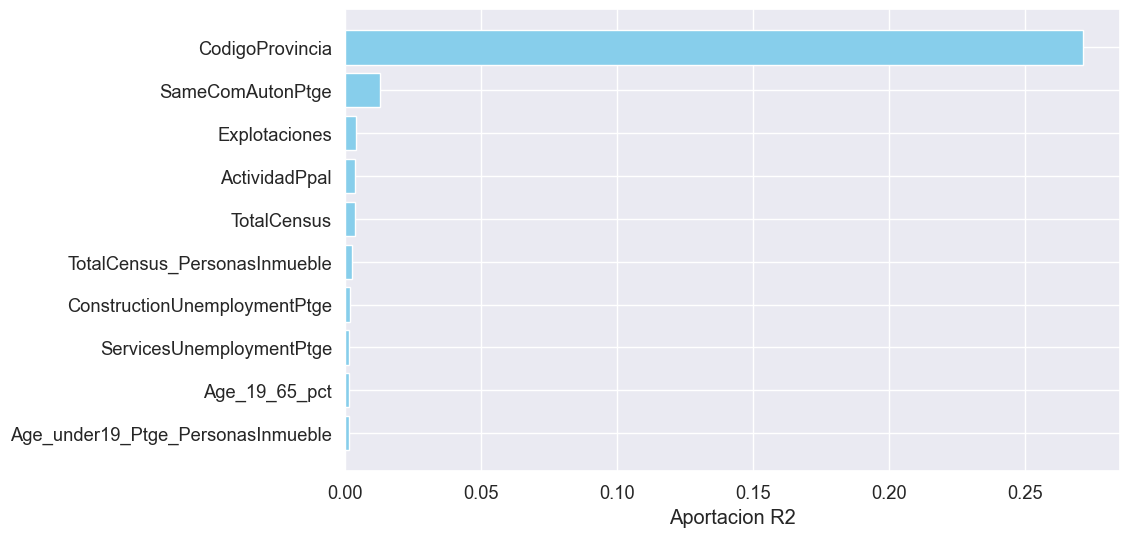

,Variables,R2
9,Age_under19_Ptge_PersonasInmueble,0.001346
5,Age_19_65_pct,0.001361
3,ServicesUnemploymentPtge,0.001444
2,ConstructionUnemploymentPtge,0.001794
8,TotalCensus_PersonasInmueble,0.002686
4,TotalCensus,0.003538
7,ActividadPpal,0.003568
1,Explotaciones,0.004034
0,SameComAutonPtge,0.013024
6,CodigoProvincia,0.271546


In [48]:
modelEffectSizes(ModeloGanador, y_train, x_train, ModeloGanador['Variables']['cont'], ModeloGanador['Variables']['categ'], ModeloGanador['Variables']['inter'])